# Lifetimes in specific FRET experiments can be misleading

In [1]:
import os
import sys

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

In [42]:
fluorophores = fl.construct_fluorophores(name="fluorophore", distance=10, count=1)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
excitation = tr.Transition(
    transition_type=tr.TransitionType.EXCITATION, rate=1e9, fluorophore_ids=[0]
)
fluorescence = tr.Transition(
    transition_type=tr.TransitionType.FLUORESCENT_EMISSION,
    rate=1e9,
    fluorophore_ids=[0],
)
isc = tr.Transition(
    transition_type=tr.TransitionType.INTERSYSTEM_CROSSING_ST, 
    rate=1e8, 
    fluorophore_ids=[0]
)
isc_2 = tr.Transition(
    transition_type=tr.TransitionType.INTERSYSTEM_CROSSING_TS, 
    rate=1e5, 
    fluorophore_ids=[0]
)
transitions = {
    "fluorophore": [excitation, fluorescence, isc, isc_2]
    }

transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()

simulation = si.Simulation(transition_set)
simulation.run(seed=4, end_time=1e-3)
analysis = an.Analysis(simulation)
fluorescence_lifetimes = analysis.get_fluorescence_lifetimes()
exp_fluorescence_lifetimes = analysis.get_emitting_transition_lifetime('fluorophore')

WARNING for line:             warnings.warn(
 Fluorophore fluorophore not known. Parameters have to be defined manually. 


In [43]:
len(exp_fluorescence_lifetimes)

907

In [45]:
fluorophores = fl.construct_fluorophores(name="fluorophore", distance=10, count=2)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
excitation = tr.Transition(
    transition_type=tr.TransitionType.EXCITATION, rate=1e9, fluorophore_ids=[0, 1]
)
fluorescence = tr.Transition(
    transition_type=tr.TransitionType.FLUORESCENT_EMISSION,
    rate=1e9,
    fluorophore_ids=[0, 1],
)
isc = tr.Transition(
    transition_type=tr.TransitionType.INTERSYSTEM_CROSSING_ST, 
    rate=1e8, 
    fluorophore_ids=[0, 1]
)
isc_2 = tr.Transition(
    transition_type=tr.TransitionType.INTERSYSTEM_CROSSING_TS, 
    rate=1e5, 
    fluorophore_ids=[1, 0]
)
tfret = tr.Transition(
    transition_type=tr.TransitionType.S_T_ANNIHILATION,
    rate=5e9,
    fluorophore_ids=[(0, 1), (1, 0)],
)
transitions = {
    "fluorophore": [excitation, fluorescence, isc, isc_2],
    "D: fluorophore, A: fluorophore, dist: 10.0": [tfret],
}

transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()

WARNING for line:             warnings.warn(
 Fluorophore fluorophore not known. Parameters have to be defined manually. 


In [46]:
rates = np.logspace(6, 14, 10)
means = []
all_exp_lifetimes = []
other_means = []
for rate in rates:
    tfret = tr.Transition(
    transition_type=tr.TransitionType.S_T_ANNIHILATION,
    rate=rate,
    fluorophore_ids=[(0, 1), (1, 0)],
    )
    transitions = {
        "fluorophore": [excitation, fluorescence, isc, isc_2],
        "D: fluorophore, A: fluorophore, dist: 10.0": [tfret],
    }
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()
    simulation = si.Simulation(transition_set)
    simulation.run(seed=4, end_time=1e-2)
    analysis = an.Analysis(simulation)
    fluorescence_lifetimes = analysis.get_fluorescence_lifetimes()
    exp_fluorescence_lifetimes = analysis.get_emitting_transition_lifetime('fluorophore')
    mean = np.mean(fluorescence_lifetimes)
    means.append(mean)
    other_mean = np.mean(exp_fluorescence_lifetimes)
    other_means.append(other_mean)
    all_exp_lifetimes.append(exp_fluorescence_lifetimes)

In [39]:
import matplotlib.pyplot as plt

In [48]:
rates

array([1.00000000e+06, 7.74263683e+06, 5.99484250e+07, 4.64158883e+08,
       3.59381366e+09, 2.78255940e+10, 2.15443469e+11, 1.66810054e+12,
       1.29154967e+13, 1.00000000e+14])

In [40]:
for exp_lifetimes in all_exp_lifetimes:
    print(len(exp_lifetimes))

2051
2113
2299
1982
2336
2328
1819
1322
1159
1158


In [55]:
b= fo.calculate_fret_rate(distance=1,
    emission_rate=2e8,
    spectral_overlap_integral=1e16,
    dipole_orientation_factor=4,
    refractive_index=1.4,)

In [56]:
f"{b:.2E}"

'1.83E+14'

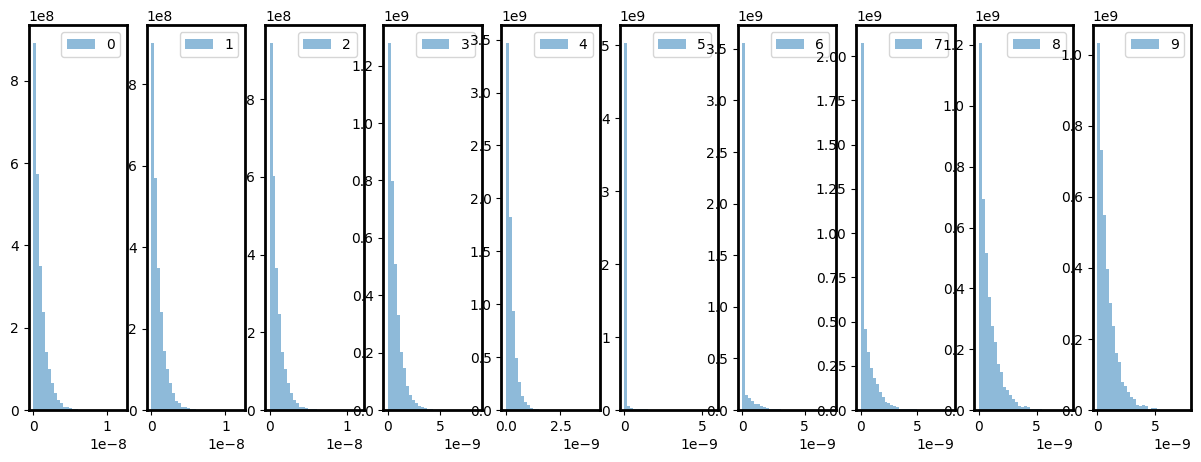

In [47]:
fig, axs = plt.subplots(1, len(all_exp_lifetimes), figsize=(15, 5))
for i, lifetimes in enumerate(all_exp_lifetimes):
    axs[i].hist(lifetimes, bins=30, density=True, alpha=0.5, label=f'{i}')
    axs[i].legend()

DIFFERENT PARAMETER SETS

In [18]:
means

[9.055182191724393e-10,
 9.025140106727998e-10,
 8.608903788142581e-10,
 6.405474075869715e-10,
 2.149760054401638e-10,
 3.6627919293141766e-11,
 6.318762920368435e-12,
 3.288386422626757e-12,
 2.138450364733841e-12,
 1.822997712762879e-12]

In [19]:
other_means

[9.048305413389895e-10,
 9.019652695218377e-10,
 8.610480808143882e-10,
 6.362006374688523e-10,
 2.2094098282629088e-10,
 8.941465820576624e-11,
 2.5319180649455904e-10,
 8.323971924108661e-10,
 9.185992923523393e-10,
 9.370633717762709e-10]

array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

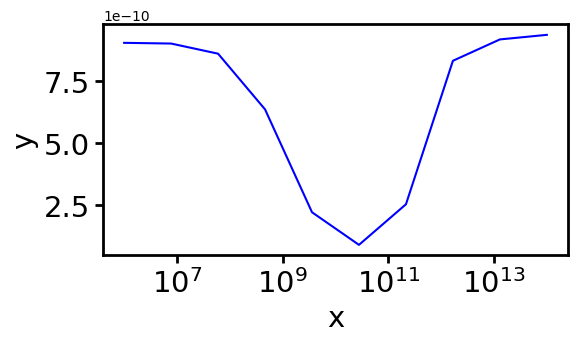

In [22]:
fi.universal_figure(data=[rates, other_means], xscale='log')